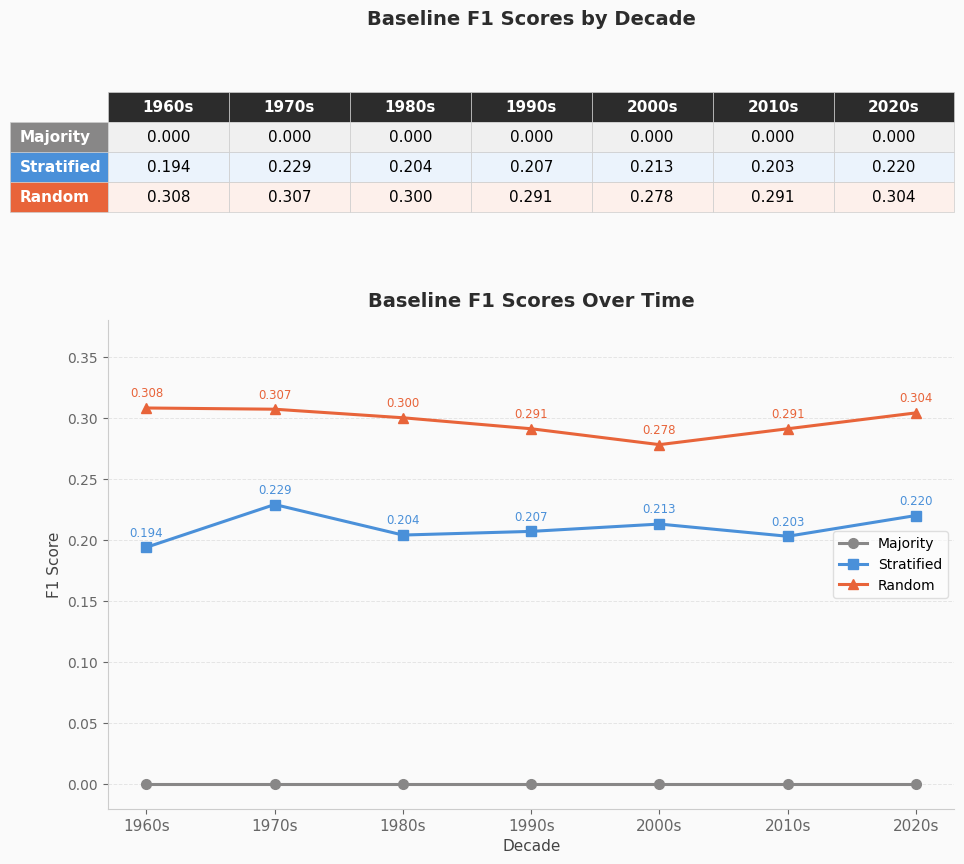

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

decades = ['1960s', '1970s', '1980s', '1990s', '2000s', '2010s', '2020s']

data = {
    'Majority':   [0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000],
    'Stratified': [0.194, 0.229, 0.204, 0.207, 0.213, 0.203, 0.220],
    'Random':     [0.308, 0.307, 0.300, 0.291, 0.278, 0.291, 0.304],
}

colors = {
    'Majority':   '#888787',
    'Stratified': '#4A90D9',
    'Random':     '#E8643A',
}

fig, (ax_table, ax_chart) = plt.subplots(2, 1, figsize=(10, 9),
                                          gridspec_kw={'height_ratios': [1, 2.2]})
fig.patch.set_facecolor('#FAFAFA')

# ── TABLE ──────────────────────────────────────────────────────────────────
ax_table.set_facecolor('#FAFAFA')
ax_table.axis('off')

row_labels = list(data.keys())
cell_text  = [[f'{v:.3f}' for v in data[bl]] for bl in row_labels]

table = ax_table.table(
    cellText=cell_text,
    rowLabels=row_labels,
    colLabels=decades,
    cellLoc='center',
    loc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.0, 1.6)

header_color  = '#2C2C2C'
majority_gray = '#F0F0F0'
strat_blue    = '#EBF3FC'
rand_orange   = '#FDF0EB'
row_colors    = [majority_gray, strat_blue, rand_orange]

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#CCCCCC')
    cell.set_linewidth(0.5)
    if row == 0:
        cell.set_facecolor(header_color)
        cell.set_text_props(color='white', fontweight='bold')
    elif col == -1:
        bl = row_labels[row - 1]
        cell.set_facecolor(colors[bl])
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor(row_colors[row - 1])

ax_table.set_title('Baseline F1 Scores by Decade', fontsize=14,
                   fontweight='bold', pad=12, color='#2C2C2C')

# ── CHART ──────────────────────────────────────────────────────────────────
ax_chart.set_facecolor('#FAFAFA')

x = np.arange(len(decades))
markers = {'Majority': 'o', 'Stratified': 's', 'Random': '^'}

for bl, vals in data.items():
    ax_chart.plot(x, vals,
                  color=colors[bl],
                  marker=markers[bl],
                  linewidth=2.2,
                  markersize=7,
                  label=bl)
    for xi, v in zip(x, vals):
        if v > 0:
            ax_chart.annotate(f'{v:.3f}', (xi, v),
                              textcoords='offset points', xytext=(0, 8),
                              ha='center', fontsize=8.5, color=colors[bl])

ax_chart.set_xticks(x)
ax_chart.set_xticklabels(decades, fontsize=11)
ax_chart.set_ylim(-0.02, 0.38)
ax_chart.set_ylabel('F1 Score', fontsize=11, color='#444444')
ax_chart.set_xlabel('Decade', fontsize=11, color='#444444')
ax_chart.set_title('Baseline F1 Scores Over Time', fontsize=14,
                   fontweight='bold', pad=10, color='#2C2C2C')
ax_chart.tick_params(colors='#666666')
ax_chart.spines[['top', 'right']].set_visible(False)
ax_chart.spines[['left', 'bottom']].set_color('#CCCCCC')
ax_chart.yaxis.grid(True, color='#E5E5E5', linewidth=0.7, linestyle='--')
ax_chart.set_axisbelow(True)
ax_chart.legend(fontsize=10, framealpha=0.6, edgecolor='#CCCCCC')

plt.tight_layout(pad=2.0)
plt.savefig('baseline_f1.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

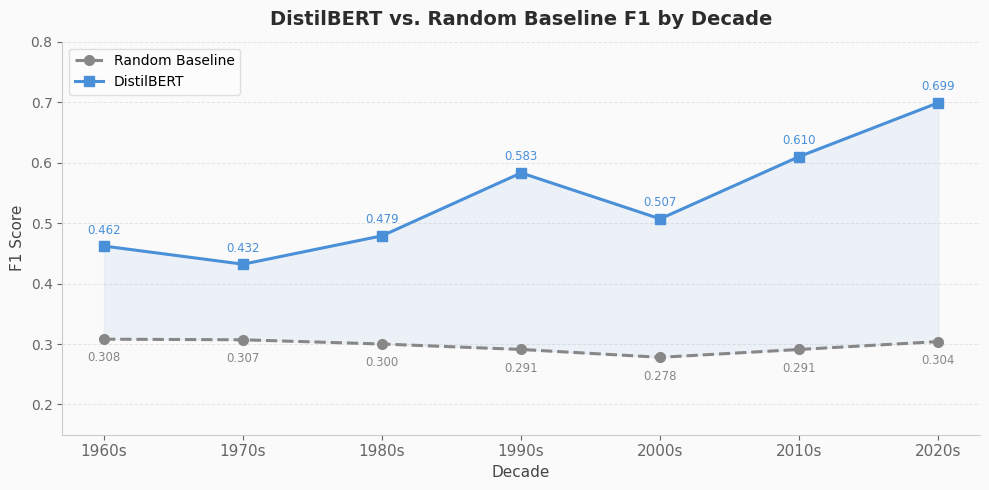

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

decades = ['1960s', '1970s', '1980s', '1990s', '2000s', '2010s', '2020s']

random_f1    = [0.308, 0.307, 0.300, 0.291, 0.278, 0.291, 0.304]
distilbert_f1 = [0.462, 0.432, 0.479, 0.583, 0.507, 0.610, 0.699]

colors = {
    'Random':     '#888787',
    'DistilBERT': '#4A90D9',
}

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

x = np.arange(len(decades))

ax.plot(x, random_f1, color=colors['Random'], marker='o', linewidth=2.2,
        markersize=7, label='Random Baseline', linestyle='--')
ax.plot(x, distilbert_f1, color=colors['DistilBERT'], marker='s', linewidth=2.2,
        markersize=7, label='DistilBERT')

for xi, v in zip(x, random_f1):
    ax.annotate(f'{v:.3f}', (xi, v), textcoords='offset points',
                xytext=(0, -16), ha='center', fontsize=8.5, color=colors['Random'])

for xi, v in zip(x, distilbert_f1):
    ax.annotate(f'{v:.3f}', (xi, v), textcoords='offset points',
                xytext=(0, 9), ha='center', fontsize=8.5, color=colors['DistilBERT'])

# shade the gap between them
ax.fill_between(x, random_f1, distilbert_f1, alpha=0.08, color=colors['DistilBERT'])

ax.set_xticks(x)
ax.set_xticklabels(decades, fontsize=11)
ax.set_ylim(0.15, 0.80)
ax.set_ylabel('F1 Score', fontsize=11, color='#444444')
ax.set_xlabel('Decade', fontsize=11, color='#444444')
ax.set_title('DistilBERT vs. Random Baseline F1 by Decade', fontsize=14,
             fontweight='bold', pad=12, color='#2C2C2C')
ax.tick_params(colors='#666666')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#CCCCCC')
ax.yaxis.grid(True, color='#E5E5E5', linewidth=0.7, linestyle='--')
ax.set_axisbelow(True)
ax.legend(fontsize=10, framealpha=0.6, edgecolor='#CCCCCC')

plt.tight_layout()
plt.savefig('distilbert_vs_random.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

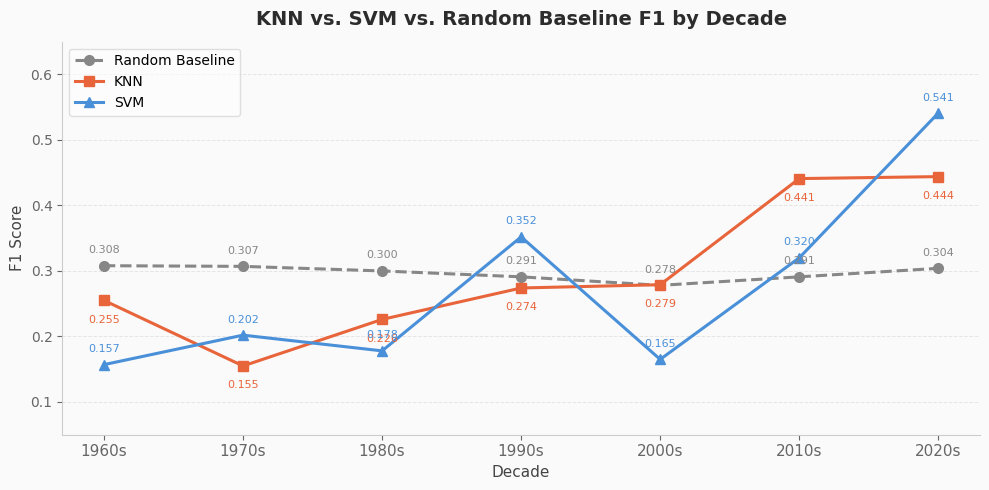

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

decades = ['1960s', '1970s', '1980s', '1990s', '2000s', '2010s', '2020s']

random_f1 = [0.308, 0.307, 0.300, 0.291, 0.278, 0.291, 0.304]
knn_f1    = [0.255, 0.155, 0.226, 0.274, 0.279, 0.441, 0.444]
svm_f1    = [0.157, 0.202, 0.178, 0.352, 0.165, 0.320, 0.541]

colors = {
    'Random': '#888787',
    'KNN':    '#E8643A',
    'SVM':    '#4A90D9',
}

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

x = np.arange(len(decades))

ax.plot(x, random_f1, color=colors['Random'], marker='o', linewidth=2.2,
        markersize=7, label='Random Baseline', linestyle='--')
ax.plot(x, knn_f1, color=colors['KNN'], marker='s', linewidth=2.2,
        markersize=7, label='KNN')
ax.plot(x, svm_f1, color=colors['SVM'], marker='^', linewidth=2.2,
        markersize=7, label='SVM')

for xi, v in zip(x, random_f1):
    ax.annotate(f'{v:.3f}', (xi, v), textcoords='offset points',
                xytext=(0, 9), ha='center', fontsize=8, color=colors['Random'])

for xi, v in zip(x, knn_f1):
    ax.annotate(f'{v:.3f}', (xi, v), textcoords='offset points',
                xytext=(0, -16), ha='center', fontsize=8, color=colors['KNN'])

for xi, v in zip(x, svm_f1):
    ax.annotate(f'{v:.3f}', (xi, v), textcoords='offset points',
                xytext=(0, 9), ha='center', fontsize=8, color=colors['SVM'])

ax.set_xticks(x)
ax.set_xticklabels(decades, fontsize=11)
ax.set_ylim(0.05, 0.65)
ax.set_ylabel('F1 Score', fontsize=11, color='#444444')
ax.set_xlabel('Decade', fontsize=11, color='#444444')
ax.set_title('KNN vs. SVM vs. Random Baseline F1 by Decade', fontsize=14,
             fontweight='bold', pad=12, color='#2C2C2C')
ax.tick_params(colors='#666666')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#CCCCCC')
ax.yaxis.grid(True, color='#E5E5E5', linewidth=0.7, linestyle='--')
ax.set_axisbelow(True)
ax.legend(fontsize=10, framealpha=0.6, edgecolor='#CCCCCC')

plt.tight_layout()
plt.savefig('knn_svm_random_f1.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

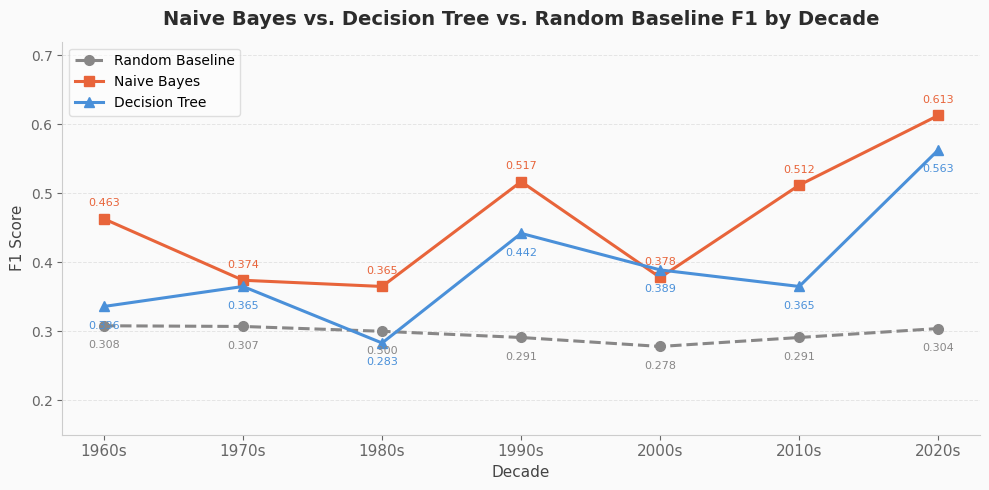

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

decades = ['1960s', '1970s', '1980s', '1990s', '2000s', '2010s', '2020s']

random_f1 = [0.308, 0.307, 0.300, 0.291, 0.278, 0.291, 0.304]
nb_f1     = [0.463, 0.374, 0.365, 0.517, 0.378, 0.512, 0.613]
dt_f1     = [0.336, 0.365, 0.283, 0.442, 0.389, 0.365, 0.563]

colors = {
    'Random':        '#888787',
    'Naive Bayes':   '#E8643A',
    'Decision Tree': '#4A90D9',
}

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

x = np.arange(len(decades))

ax.plot(x, random_f1, color=colors['Random'], marker='o', linewidth=2.2,
        markersize=7, label='Random Baseline', linestyle='--')
ax.plot(x, nb_f1, color=colors['Naive Bayes'], marker='s', linewidth=2.2,
        markersize=7, label='Naive Bayes')
ax.plot(x, dt_f1, color=colors['Decision Tree'], marker='^', linewidth=2.2,
        markersize=7, label='Decision Tree')

for xi, v in zip(x, random_f1):
    ax.annotate(f'{v:.3f}', (xi, v), textcoords='offset points',
                xytext=(0, -16), ha='center', fontsize=8, color=colors['Random'])

for xi, v in zip(x, nb_f1):
    ax.annotate(f'{v:.3f}', (xi, v), textcoords='offset points',
                xytext=(0, 9), ha='center', fontsize=8, color=colors['Naive Bayes'])

for xi, v in zip(x, dt_f1):
    ax.annotate(f'{v:.3f}', (xi, v), textcoords='offset points',
                xytext=(0, -16), ha='center', fontsize=8, color=colors['Decision Tree'])

ax.set_xticks(x)
ax.set_xticklabels(decades, fontsize=11)
ax.set_ylim(0.15, 0.72)
ax.set_ylabel('F1 Score', fontsize=11, color='#444444')
ax.set_xlabel('Decade', fontsize=11, color='#444444')
ax.set_title('Naive Bayes vs. Decision Tree vs. Random Baseline F1 by Decade', fontsize=14,
             fontweight='bold', pad=12, color='#2C2C2C')
ax.tick_params(colors='#666666')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#CCCCCC')
ax.yaxis.grid(True, color='#E5E5E5', linewidth=0.7, linestyle='--')
ax.set_axisbelow(True)
ax.legend(fontsize=10, framealpha=0.6, edgecolor='#CCCCCC')

plt.tight_layout()
plt.savefig('nb_dt_random_f1.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

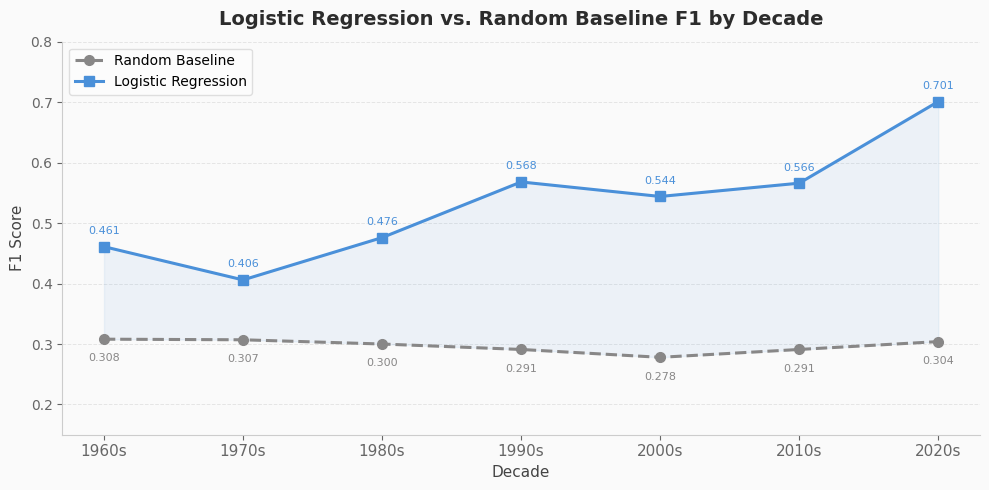

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

decades = ['1960s', '1970s', '1980s', '1990s', '2000s', '2010s', '2020s']

random_f1 = [0.308, 0.307, 0.300, 0.291, 0.278, 0.291, 0.304]
lr_f1     = [0.461, 0.406, 0.476, 0.568, 0.544, 0.566, 0.701]

colors = {
    'Random': '#888787',
    'Logistic Regression': '#4A90D9',
}

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

x = np.arange(len(decades))

ax.plot(x, random_f1, color=colors['Random'], marker='o', linewidth=2.2,
        markersize=7, label='Random Baseline', linestyle='--')
ax.plot(x, lr_f1, color=colors['Logistic Regression'], marker='s', linewidth=2.2,
        markersize=7, label='Logistic Regression')

for xi, v in zip(x, random_f1):
    ax.annotate(f'{v:.3f}', (xi, v), textcoords='offset points',
                xytext=(0, -16), ha='center', fontsize=8, color=colors['Random'])

for xi, v in zip(x, lr_f1):
    ax.annotate(f'{v:.3f}', (xi, v), textcoords='offset points',
                xytext=(0, 9), ha='center', fontsize=8, color=colors['Logistic Regression'])

ax.fill_between(x, random_f1, lr_f1, alpha=0.08, color=colors['Logistic Regression'])

ax.set_xticks(x)
ax.set_xticklabels(decades, fontsize=11)
ax.set_ylim(0.15, 0.80)
ax.set_ylabel('F1 Score', fontsize=11, color='#444444')
ax.set_xlabel('Decade', fontsize=11, color='#444444')
ax.set_title('Logistic Regression vs. Random Baseline F1 by Decade', fontsize=14,
             fontweight='bold', pad=12, color='#2C2C2C')
ax.tick_params(colors='#666666')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#CCCCCC')
ax.yaxis.grid(True, color='#E5E5E5', linewidth=0.7, linestyle='--')
ax.set_axisbelow(True)
ax.legend(fontsize=10, framealpha=0.6, edgecolor='#CCCCCC')

plt.tight_layout()
plt.savefig('lr_random_f1.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

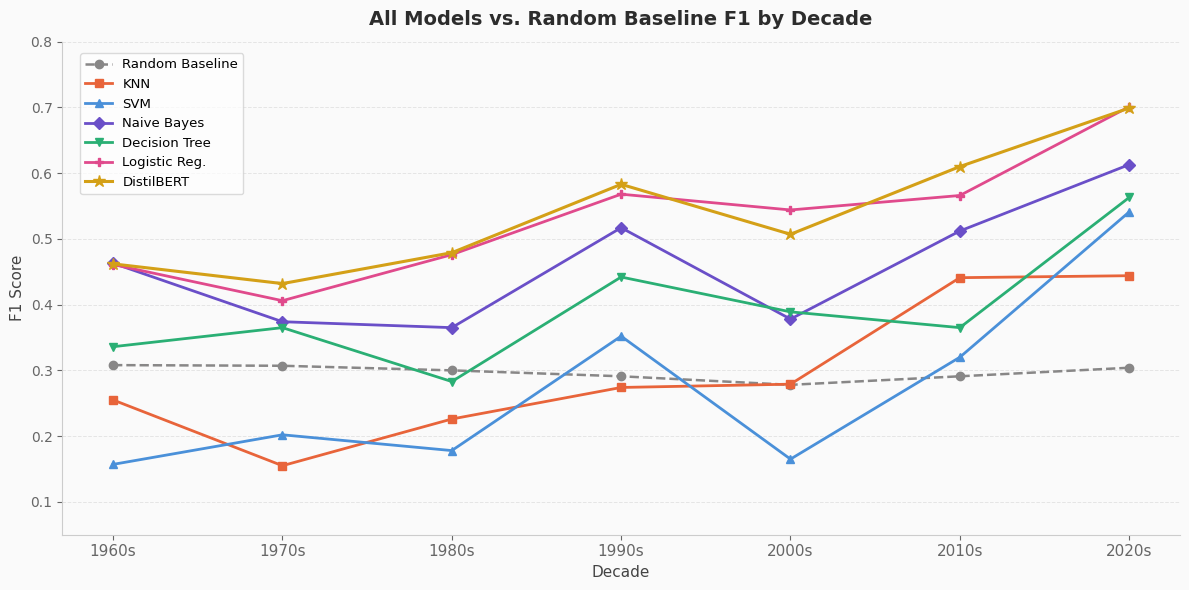

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

decades = ['1960s', '1970s', '1980s', '1990s', '2000s', '2010s', '2020s']

models = {
    'Random Baseline': [0.308, 0.307, 0.300, 0.291, 0.278, 0.291, 0.304],
    'KNN':             [0.255, 0.155, 0.226, 0.274, 0.279, 0.441, 0.444],
    'SVM':             [0.157, 0.202, 0.178, 0.352, 0.165, 0.320, 0.541],
    'Naive Bayes':     [0.463, 0.374, 0.365, 0.517, 0.378, 0.512, 0.613],
    'Decision Tree':   [0.336, 0.365, 0.283, 0.442, 0.389, 0.365, 0.563],
    'Logistic Reg.':   [0.461, 0.406, 0.476, 0.568, 0.544, 0.566, 0.701],
    'DistilBERT':      [0.462, 0.432, 0.479, 0.583, 0.507, 0.610, 0.699],
}

styles = {
    'Random Baseline': {'color': '#888787', 'marker': 'o', 'linestyle': '--', 'linewidth': 1.8, 'markersize': 6},
    'KNN':             {'color': '#E8643A', 'marker': 's', 'linestyle': '-',  'linewidth': 2.0, 'markersize': 6},
    'SVM':             {'color': '#4A90D9', 'marker': '^', 'linestyle': '-',  'linewidth': 2.0, 'markersize': 6},
    'Naive Bayes':     {'color': '#6A4FC8', 'marker': 'D', 'linestyle': '-',  'linewidth': 2.0, 'markersize': 6},
    'Decision Tree':   {'color': '#2AAF74', 'marker': 'v', 'linestyle': '-',  'linewidth': 2.0, 'markersize': 6},
    'Logistic Reg.':   {'color': '#E04A8C', 'marker': 'P', 'linestyle': '-',  'linewidth': 2.0, 'markersize': 6},
    'DistilBERT':      {'color': '#D4A017', 'marker': '*', 'linestyle': '-',  'linewidth': 2.2, 'markersize': 9},
}

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

x = np.arange(len(decades))

for model, vals in models.items():
    ax.plot(x, vals, label=model, **styles[model])

ax.set_xticks(x)
ax.set_xticklabels(decades, fontsize=11)
ax.set_ylim(0.05, 0.80)
ax.set_ylabel('F1 Score', fontsize=11, color='#444444')
ax.set_xlabel('Decade', fontsize=11, color='#444444')
ax.set_title('All Models vs. Random Baseline F1 by Decade', fontsize=14,
             fontweight='bold', pad=12, color='#2C2C2C')
ax.tick_params(colors='#666666')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#CCCCCC')
ax.yaxis.grid(True, color='#E5E5E5', linewidth=0.7, linestyle='--')
ax.set_axisbelow(True)
ax.legend(fontsize=9.5, framealpha=0.7, edgecolor='#CCCCCC',
          loc='upper left', bbox_to_anchor=(0.01, 0.99))

plt.tight_layout()
plt.savefig('all_models_f1.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()